In [76]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [77]:
data = pd.read_csv("C:\\Users\\prern\\Downloads\\loan_sanction_test.csv")
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [79]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [80]:
data.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [81]:
data['Property_Area'].value_counts()

Property_Area
Urban        140
Semiurban    116
Rural        111
Name: count, dtype: int64

In [82]:
data['Gender'].value_counts()

Gender
Male      286
Female     70
Name: count, dtype: int64

In [83]:
data['Self_Employed'].value_counts()

Self_Employed
No     307
Yes     37
Name: count, dtype: int64

In [84]:
data['Credit_History'].value_counts()

Credit_History
1.0    279
0.0     59
Name: count, dtype: int64

In [85]:
# Dependents shows how many people the applicant financially supports, which affects how much money they have left to repay the loan.

data['Dependents'].value_counts() 

Dependents
0     200
2      59
1      58
3+     40
Name: count, dtype: int64

In [86]:
data['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    311
180.0     22
480.0      8
300.0      7
240.0      4
84.0       3
60.0       1
12.0       1
350.0      1
36.0       1
120.0      1
6.0        1
Name: count, dtype: int64

In [87]:
data.fillna({'Credit_History':1},inplace=True)

In [88]:
data.fillna({'LoanAmount':0},inplace=True)

In [89]:
data.fillna({'Self_Employed' : 'No'},inplace = True)  

In [90]:
# here, we have convert the missing/NA values in to the mode 

data['Dependents'].fillna(data['Dependents'].mode()[0],inplace=True)  

C:\Users\prern\AppData\Local\Temp\ipykernel_25332\1730499624.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Dependents'].fillna(data['Dependents'].mode()[0],inplace=True)


In [91]:
data['Dependents'] = data['Dependents'].replace('3+', 3)  

# here, '+3' is considered as a text form, so we changed it into the numerical.

In [92]:
data.fillna({'LoanAmount':100},inplace=True)   # Filled with the median 

In [93]:
data.fillna({'Loan_Amount_Term': 360},inplace=True)  # Filled with median

In [94]:
data.fillna({'Gender':'Male'},inplace=True)   # Filled with median as no relatable info provided

In [95]:
data.head(12)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0,59.0,360.0,1.0,Semiurban
7,LP001056,Male,Yes,2,Not Graduate,No,3881,0,147.0,360.0,0.0,Rural
8,LP001059,Male,Yes,2,Graduate,No,13633,0,280.0,240.0,1.0,Urban
9,LP001067,Male,No,0,Not Graduate,No,2400,2400,123.0,360.0,1.0,Semiurban


In [96]:
data['Self_Employed'].value_counts()

Self_Employed
No     330
Yes     37
Name: count, dtype: int64

In [97]:
len(data)

367

In [98]:
data['Credit_History'].value_counts()

Credit_History
1.0    308
0.0     59
Name: count, dtype: int64

In [99]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

data is cleaned with the help of median.

In [100]:
data.corr(numeric_only=True)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.110335,0.458769,0.023319,0.094944
CoapplicantIncome,-0.110335,1.000000,0.144788,-0.008633,-0.058004
LoanAmount,0.458769,0.144788,1.000000,0.071673,-0.009628
Loan_Amount_Term,0.023319,-0.008633,0.071673,1.000000,-0.048189
Credit_History,0.094944,-0.058004,-0.009628,-0.048189,1.000000


In [101]:
data.head(12)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0,59.0,360.0,1.0,Semiurban
7,LP001056,Male,Yes,2,Not Graduate,No,3881,0,147.0,360.0,0.0,Rural
8,LP001059,Male,Yes,2,Graduate,No,13633,0,280.0,240.0,1.0,Urban
9,LP001067,Male,No,0,Not Graduate,No,2400,2400,123.0,360.0,1.0,Semiurban


In [102]:
data['Self_Employed'].value_counts()

Self_Employed
No     330
Yes     37
Name: count, dtype: int64

In [103]:
data['Credit_History'].value_counts()

Credit_History
1.0    308
0.0     59
Name: count, dtype: int64

## Spread of Numerical columns

In [104]:
numerical_cols = data.select_dtypes(include="number").columns.tolist()
numerical_cols

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

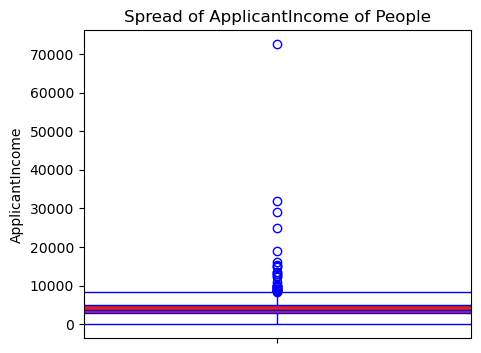

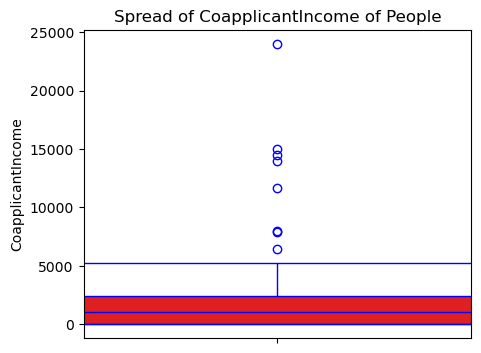

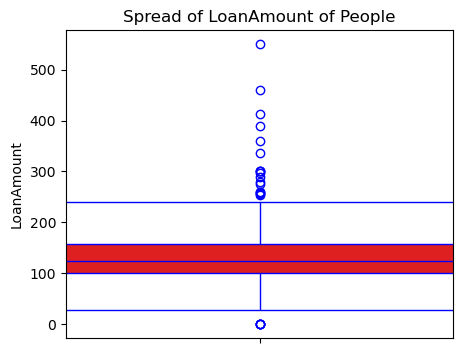

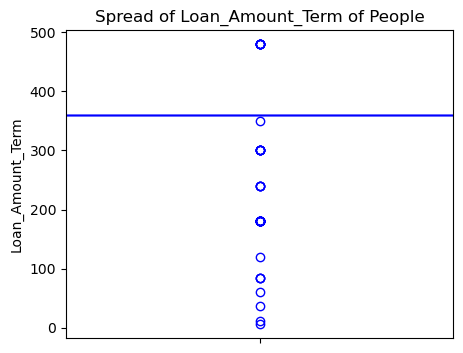

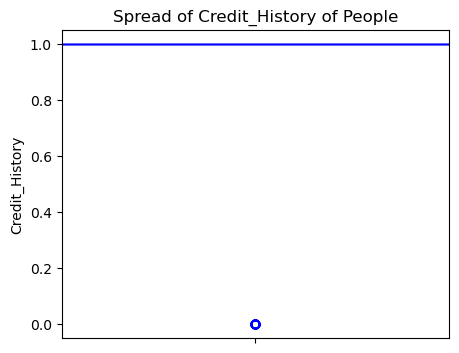

In [105]:
for col in numerical_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data[col], color="red", gap=40, linecolor="blue", linewidth=1)
    plt.title(f"Spread of {col} of People")


## Overview of Categorical Columns

In [106]:
categorical_cols = data.select_dtypes(include = "object").columns.tolist()

In [107]:
categorical_cols

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area']

In [108]:
categorical_cols.remove("Loan_ID")

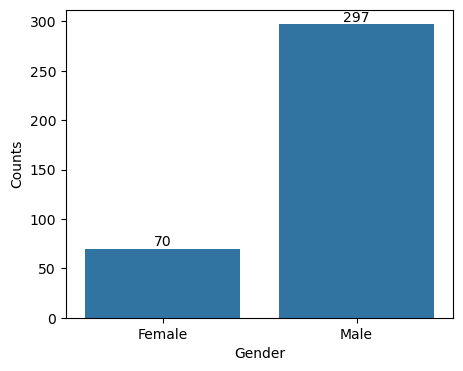

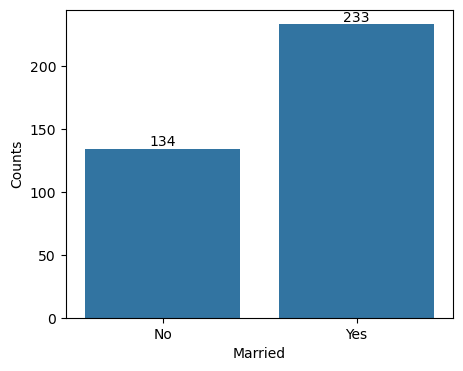

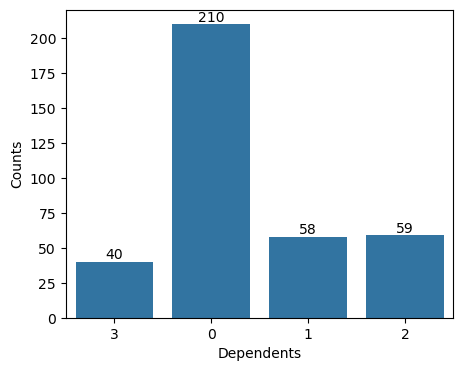

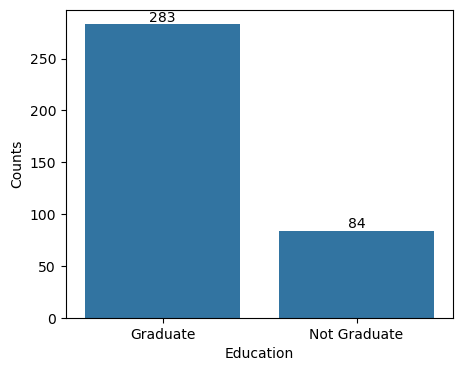

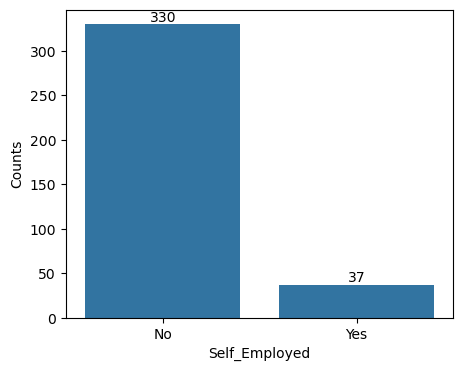

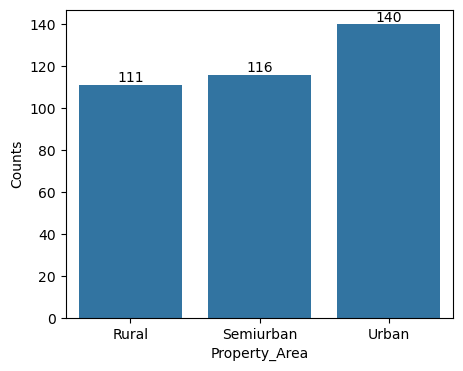

In [109]:
for col in categorical_cols:
    result = data.groupby(col).agg(Counts=("Loan_ID", "count")).reset_index()
    
    plt.figure(figsize=(5, 4))
    ax = sns.barplot(x=result[col], y=result['Counts'])
    ax.bar_label(ax.containers[0])

#### 1.  80% applicants are male, female are only 20%.
#### 2. Married(233) applicants count is greater than unmarried(134)
#### 3. 0 Dependents applicants have high count(210).
#### 4. In Education, 283 applicants are Graduate.
#### 5. 89% applicants are NOT Self-Employed. Only 11% Applicants are self-Employed.
#### 6. Highest 38% Applicants come from Urban Area and 2nd highest is Semi-Urban Area with 31%.

In [110]:
data[numerical_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,367.000000,367.000000,367.000000
mean,4805.599455,1569.577657,134.277929,342.822888,0.839237
std,4910.685399,2334.232099,62.961426,64.658402,0.367814
min,0.000000,0.000000,0.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.000000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,157.500000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [111]:
sc = data.groupby('Credit_History')['Self_Employed'].value_counts().unstack()  
sc

Self_Employed,No,Yes
Credit_History,,
0.0,57,2
1.0,273,35


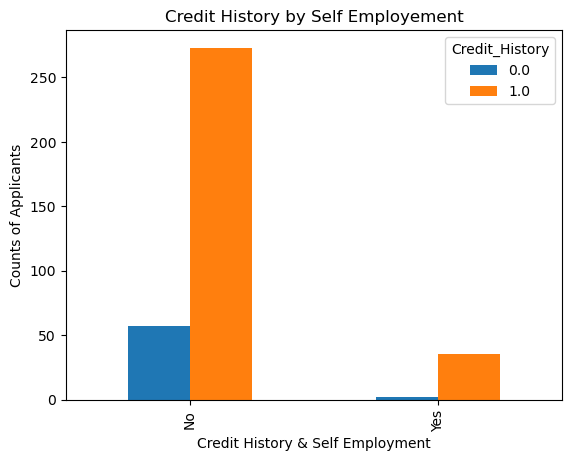

In [112]:
sc = data.groupby('Self_Employed')['Credit_History'].value_counts().unstack()

sc.plot(kind='bar')
plt.xlabel("Credit History & Self Employment")
plt.ylabel("Counts of Applicants")
plt.title("Credit History by Self Employement")
plt.show()

#### Applicants with higher credit history are not self employed but favourable, while self employed applicants have lower credit history.
#### This reflects the high fluctuation in the income of self-employed applicants who are unable to maintain the credit score.

In [132]:
dc = data.groupby('Credit_History')['Dependents'].value_counts().unstack()
dc

Dependents,3,0,1,2
Credit_History,,,,
0.0,9,33,6,11
1.0,31,177,52,48


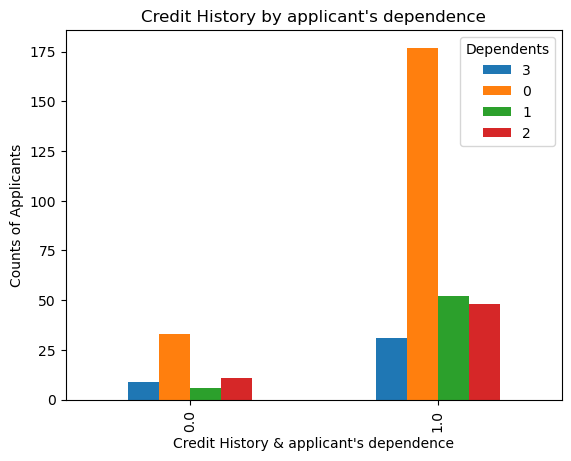

In [133]:
dc.plot(kind='bar')
plt.xlabel("Credit History & applicant's dependence")
plt.ylabel("Counts of Applicants")
plt.title("Credit History by applicant's dependence")
plt.show()

#### This bar chart shows the credit history of applicants by their dependency
#### where applicants with zero dependency have higher credit score as commpare to other. 
#### applicants with dependency more than 1 shows the financial risk in repayment of loan and will face the high financial pressure.

In [115]:
dm = data.groupby('Dependents')['Married'].value_counts().unstack()
dm

Married,No,Yes
Dependents,,
3,5,35
0,110,100
1,13,45
2,6,53


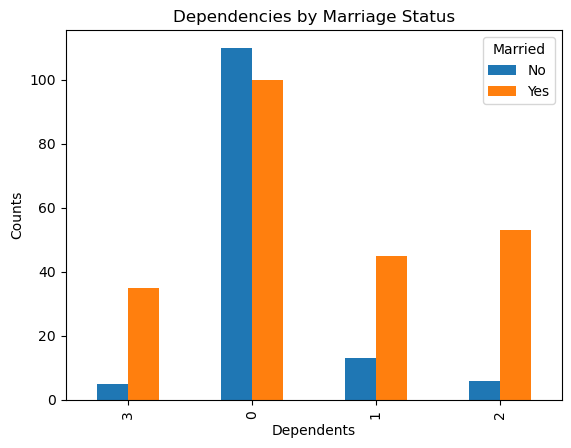

In [116]:
dm.plot(kind= 'bar')
plt.xlabel("Dependents")
plt.ylabel("Counts")
plt.title("Dependencies by Marriage Status")
plt.show()

In [117]:
sp = data.groupby('Property_Area')['Self_Employed'].value_counts().unstack()
sp

Self_Employed,No,Yes
Property_Area,,
Rural,93,18
Semiurban,108,8
Urban,129,11


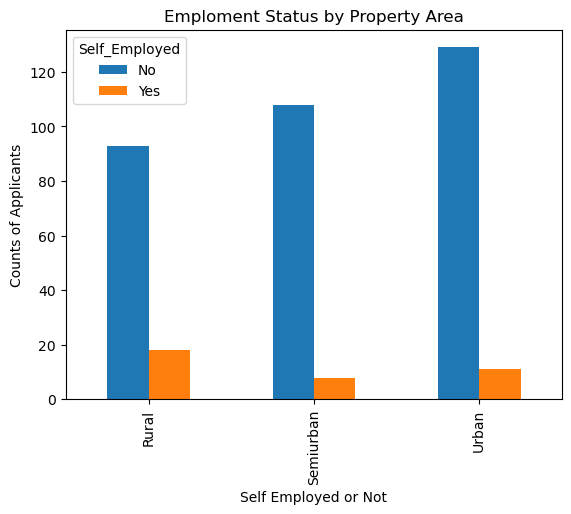

In [118]:
sp.plot(kind='bar')
plt.xlabel("Self Employed or Not")
plt.ylabel("Counts of Applicants")
plt.title("Emploment Status by Property Area")
plt.show()

#### In Rural Area 18 Applicants are Self-employed
#### 

In [120]:
income_dep = data.groupby('Dependents')['ApplicantIncome'].mean()
income_dep

Dependents
3    6952.275000
0    4384.376190
1    4781.103448
2    4873.576271
Name: ApplicantIncome, dtype: float64

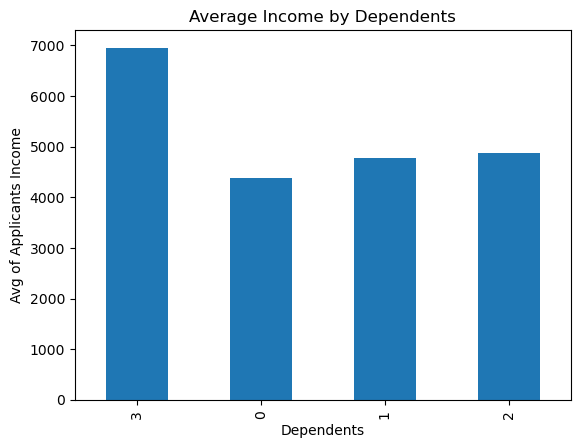

In [128]:
income_dep.plot(kind='bar')
plt.xlabel("Dependents")
plt.ylabel("Avg of Applicants Income")
plt.title("Average Income by Dependents")
plt.show()

#### This shows the financial responsibility patterns among the applicants based on their dependencies.
#### People with more Dependencies earning more income than others.

In [125]:
loan_dep = data.groupby('Dependents')['LoanAmount'].mean()
loan_dep

Dependents
3    146.350000
0    127.976190
1    128.637931
2    154.067797
Name: LoanAmount, dtype: float64

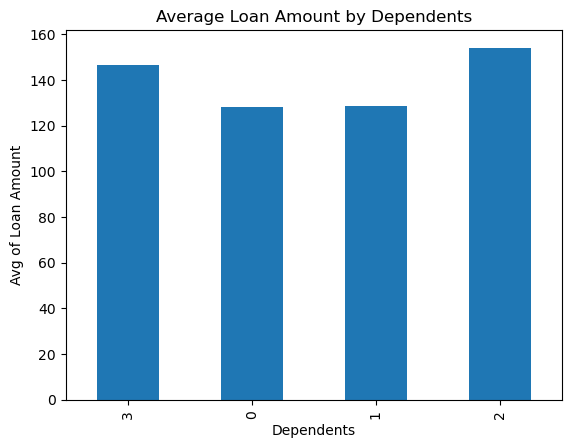

In [126]:
loan_dep.plot(kind='bar')
plt.xlabel("Dependents")
plt.ylabel("Avg of Loan Amount")
plt.title("Average Loan Amount by Dependents")
plt.show()

#### Applicants with 2 Dependency have the highest average requested Loan amount, 2nd highest is with dependency 3. 